<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
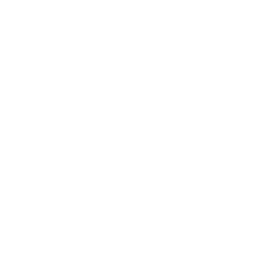
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Electoral Precinct Voting Pattern Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Government / Election Statistics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This analysis examines whether political party affiliation varies systematically across precinct types (urban, suburban, rural) in a simulated county election dataset of 500 precincts. PROC FREQ first runs the omnibus Pearson chi-square test of general association, which is highly significant (chi-square = 39.94, 6 df, p < 0.0001; Cramer's V = 0.20): party composition is clearly not independent of precinct type. We then complement that general result with the **Cochran-Armitage trend test**, a focused single-degree-of-freedom test that exploits the natural urban-to-rural ordering and asks a sharper, directional question: does Party A support decline monotonically along that gradient? The trend test reports an exact p-value alongside the asymptotic one. The analytical point of this example is the division of labour between the two tests: the omnibus chi-square establishes *that* the parties differ across precinct types, while the ordered trend test pins the effect down to a specific monotonic decline in Party A support from urban to rural precincts (trend chi-square = 30.48, p < 0.0001).

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | Precinct-level records, one row per precinct, with precinct type, county, and the plurality party | 500 |

The dataset is generated in the DATA step below with a fixed random seed (`call streaminit(42)`), so the results are fully reproducible. Party affiliation is drawn from a type-dependent distribution: Party A is most likely in urban precincts and least likely in rural ones, which is the urban-to-rural gradient the analysis sets out to detect and quantify.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic precinct-level voting data
   Small cell counts in rural precincts to demonstrate
   need for exact tests
   -------------------------------------------------------- */
data work.precinct_votes;
    call streaminit(42);
    array party_list[4] $15 _temporary_ ('PARTY_A' 'PARTY_B' 'PARTY_C' 'INDEPENDENT');
    array type_list[3] $10 _temporary_ ('URBAN' 'SUBURBAN' 'RURAL');
    array county_list[5] $15 _temporary_ ('JEFFERSON' 'HAMILTON' 'MADISON' 'ADAMS' 'MONROE');
    do precinct_seq = 1 to 500;
        precinct_id = cat('PCT-', put(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        county_name = county_list[county_idx];
        /* Assign precinct type with weighting */
        type_prob = rand('uniform');
        if type_prob < 0.30 then precinct_type = 'URBAN';
        else if type_prob < 0.65 then precinct_type = 'SUBURBAN';
        else precinct_type = 'RURAL';
        /* Assign party with type-dependent distribution */
        party_prob = rand('uniform');
        if precinct_type = 'URBAN' then do;
            if party_prob < 0.55 then party = 'PARTY_A';
            else if party_prob < 0.80 then party = 'PARTY_B';
            else if party_prob < 0.92 then party = 'PARTY_C';
            else party = 'INDEPENDENT';
        end;
        else if precinct_type = 'SUBURBAN' then do;
            if party_prob < 0.40 then party = 'PARTY_A';
            else if party_prob < 0.75 then party = 'PARTY_B';
            else if party_prob < 0.88 then party = 'PARTY_C';
            else party = 'INDEPENDENT';
        end;
        else do; /* RURAL - smaller cells for minority parties */
            if party_prob < 0.25 then party = 'PARTY_A';
            else if party_prob < 0.70 then party = 'PARTY_B';
            else if party_prob < 0.85 then party = 'PARTY_C';
            else party = 'INDEPENDENT';
        end;
        /* Vote count varies by precinct type */
        if precinct_type = 'URBAN' then
            vote_count = int(rand('normal', 120, 40));
        else if precinct_type = 'SUBURBAN' then
            vote_count = int(rand('normal', 80, 25));
        else
            vote_count = int(rand('normal', 25, 12));
        if vote_count < 1 then vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        output;
    end;
    drop precinct_seq county_idx type_prob party_prob;
run;

NOTE: DATA work.precinct_votes


NOTE: Wrote work.precinct_votes (500 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                                   The FREQ Procedure

precinct_type    Frequency    Percent
--------------------------------------
RURAL                  180     36.00
SUBURBAN               166     33.20
URBAN                  154     30.80

party          Frequency    Percent
------------------------------------
INDEPENDENT           57     11.40
PARTY_A              189     37.80
PARTY_B              174     34.80
PARTY_C               80     16.00


NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


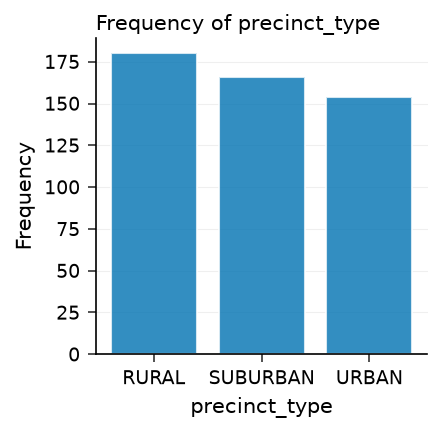

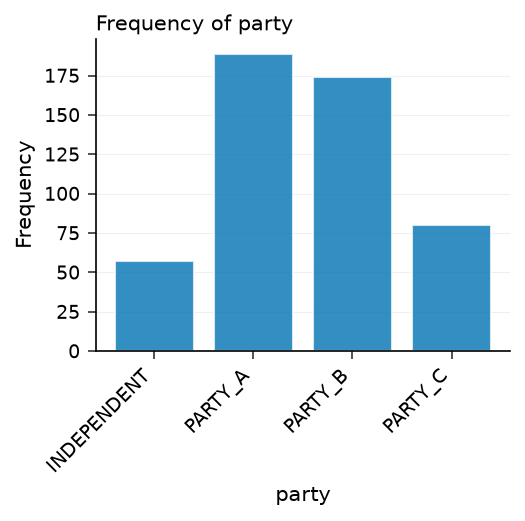

In [2]:
/* --------------------------------------------------------
   Baseline precinct type and party distribution
   -------------------------------------------------------- */
proc freq data=work.precinct_votes;
    tables precinct_type / nocum;
    tables party / nocum;
run;

---

NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


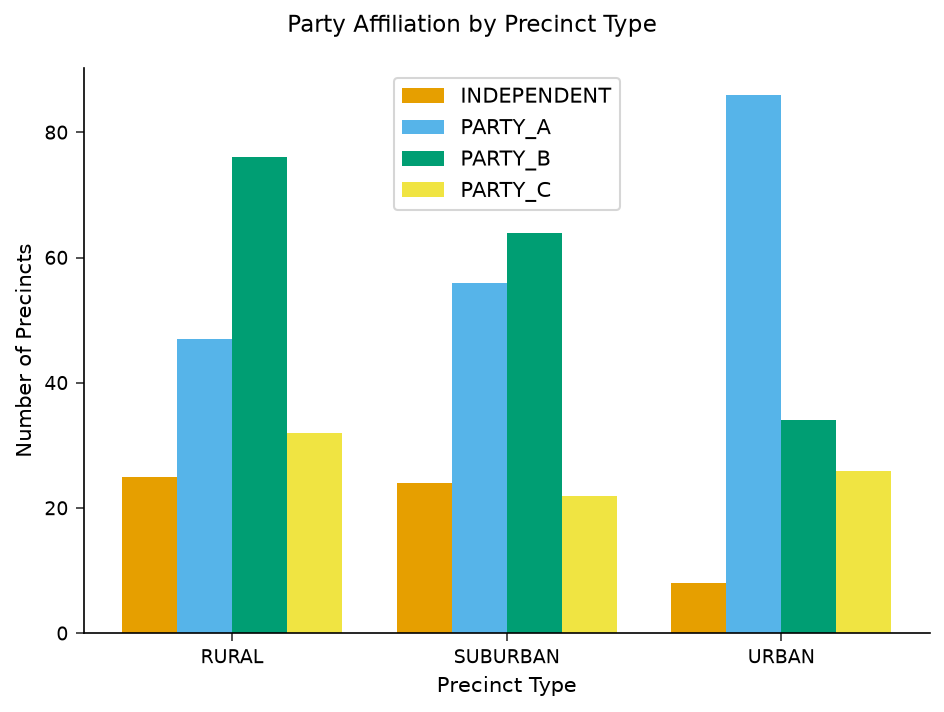

In [3]:
/* --------------------------------------------------------
   Party affiliation by precinct type (precinct counts)
   -------------------------------------------------------- */
proc sgplot data=work.precinct_votes;
    vbar precinct_type / group=party groupdisplay=cluster
        stat=freq;
    xaxis label='Precinct Type';
    yaxis label='Number of Precincts';
    title 'Party Affiliation by Precinct Type';
run;

---

                             Precinct Type by Party: Cross-Tabulation with Expected Counts                              

                                                   The FREQ Procedure

Table of precinct_type by party

precinct_type |INDEPENDENT |    PARTY_A |    PARTY_B |    PARTY_C |       Total
--------------+------------+------------+------------+------------+------------
RURAL         |         25 |         47 |         76 |         32 |         180
              |       5.00 |       9.40 |      15.20 |       6.40 |       36.00
              |      20.52 |      68.04 |      62.64 |      28.80 |            
              |      13.89 |      26.11 |      42.22 |      17.78 |      100.00
              |      43.86 |      24.87 |      43.68 |      40.00 |       36.00
--------------+------------+------------+------------+------------+------------
SUBURBAN      |         24 |         56 |         64 |         22 |         166
              |       4.80 |      11.20 |      12.80 |

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


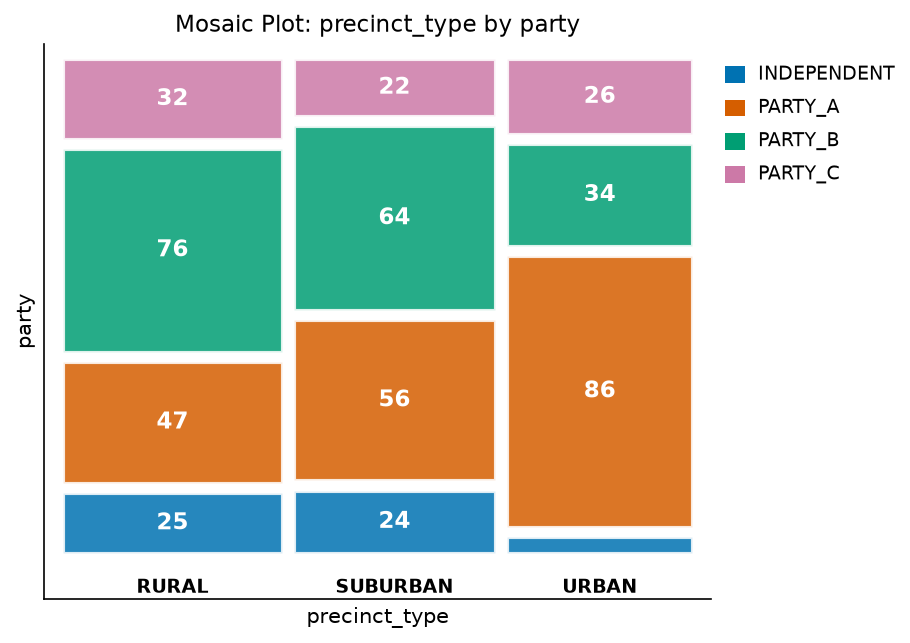

In [4]:
/* --------------------------------------------------------
   Precinct type x party cross-tabulation.
   Request EXPECTED counts and the Pearson chi-square test
   of general association. With 500 precincts every expected
   count is comfortably above five (the smallest is about
   17.6), so the omnibus chi-square is well conditioned and
   establishes THAT party composition depends on precinct
   type -- the next cell asks the sharper directional question.
   -------------------------------------------------------- */
proc freq data=work.precinct_votes;
    tables precinct_type * party / chisq expected;
    title 'Precinct Type by Party: Cross-Tabulation with Expected Counts';
run;

                         Cochran-Armitage Trend Test: Party A Support Across Precinct Gradient                          

                                                   The FREQ Procedure

Table of type_order by party_a_flag

type_order |         0 |         1 |      Total
-----------+-----------+-----------+-----------
1          |        68 |        86 |        154
           |     13.60 |     17.20 |      30.80
           |     44.16 |     55.84 |     100.00
           |     21.86 |     45.50 |      30.80
-----------+-----------+-----------+-----------
2          |       110 |        56 |        166
           |     22.00 |     11.20 |      33.20
           |     66.27 |     33.73 |     100.00
           |     35.37 |     29.63 |      33.20
-----------+-----------+-----------+-----------
3          |       133 |        47 |        180
           |     26.60 |      9.40 |      36.00
           |     73.89 |     26.11 |     100.00
           |     42.77 |     24.87 |      36.00
--

NOTE: DATA work.precinct_ordinal


NOTE: Read 500 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (500 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


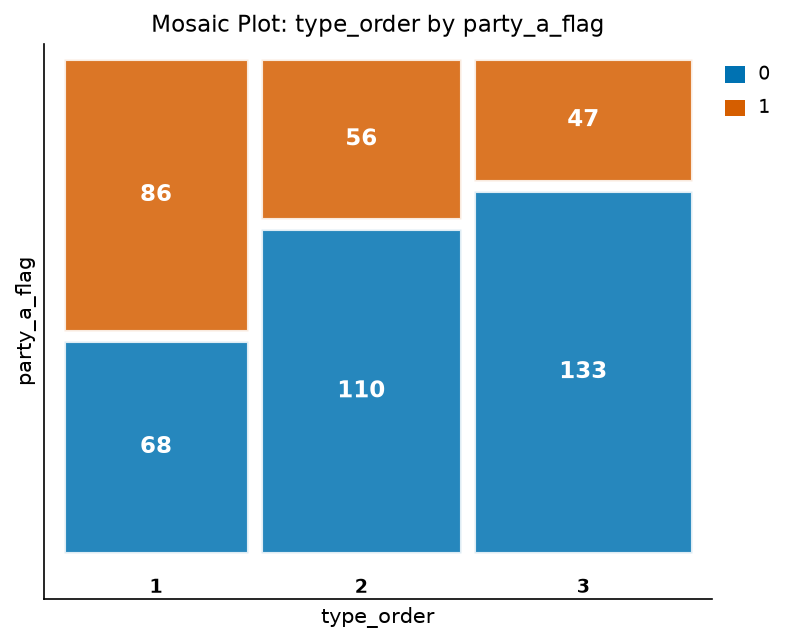

In [5]:
/* --------------------------------------------------------
   Cochran-Armitage trend test. Recode precinct type to an
   ordinal score (1=Urban, 2=Suburban, 3=Rural) and test
   whether Party A support shows a monotonic trend across
   the gradient. Unlike the omnibus chi-square, this is a
   single-degree-of-freedom, directional test. EXACT TREND
   adds the exact p-value alongside the asymptotic one.
   -------------------------------------------------------- */
data work.precinct_ordinal;
    set work.precinct_votes;
    /* Ordinal coding: 1=Urban, 2=Suburban, 3=Rural */
    if precinct_type = 'URBAN' then type_order = 1;
    else if precinct_type = 'SUBURBAN' then type_order = 2;
    else type_order = 3;
    /* Binary outcome: Party A vs. all other affiliations */
    party_a_flag = (party = 'PARTY_A');
run;

proc freq data=work.precinct_ordinal;
    tables type_order * party_a_flag / chisq trend;
    exact trend;
    title 'Cochran-Armitage Trend Test: Party A Support Across Precinct Gradient';
run;

                                        Precinct Type Distribution Within County                                        

                                                   The FREQ Procedure

Table of county_name by precinct_type

county_name |     RURAL |  SUBURBAN |     URBAN |      Total
------------+-----------+-----------+-----------+-----------
ADAMS       |        30 |        45 |        19 |         94
            |      6.00 |      9.00 |      3.80 |      18.80
            |     31.91 |     47.87 |     20.21 |     100.00
            |     16.67 |     27.11 |     12.34 |      18.80
------------+-----------+-----------+-----------+-----------
HAMILTON    |        40 |        32 |        37 |        109
            |      8.00 |      6.40 |      7.40 |      21.80
            |     36.70 |     29.36 |     33.94 |     100.00
            |     22.22 |     19.28 |     24.03 |      21.80
------------+-----------+-----------+-----------+-----------
JEFFERSON   |        33 |        30 

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


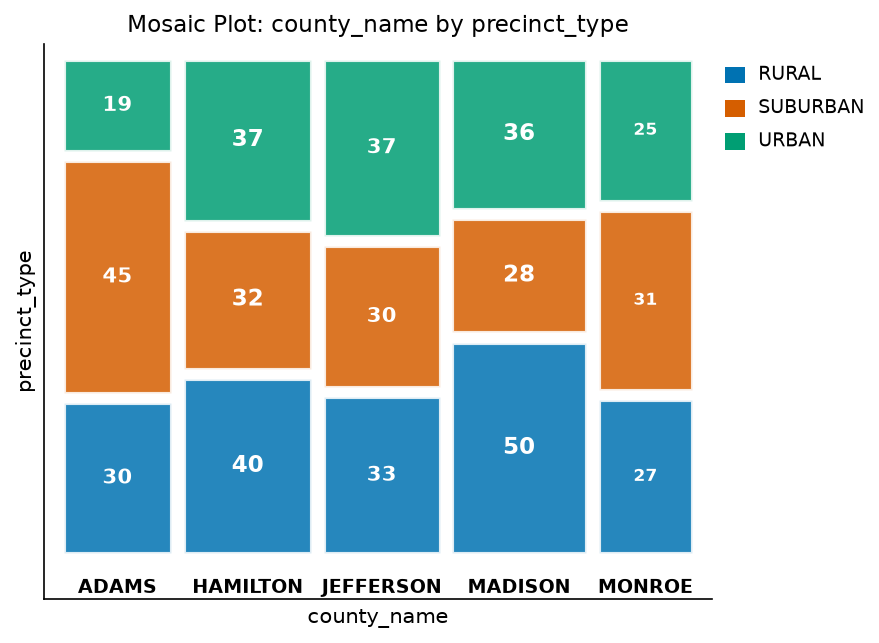

In [6]:
/* --------------------------------------------------------
   County-level view: how the urban/suburban/rural mix
   varies across the five counties. This contextualizes the
   trend result -- the precinct gradient is present in every
   county, but its composition differs.
   -------------------------------------------------------- */
proc freq data=work.precinct_votes;
    tables county_name * precinct_type / nocum;
    title 'Precinct Type Distribution Within County';
run;

---

### Interpretation

Across the 500 precincts, Party A holds a plurality overall (189 precincts, 37.8%), followed by Party B (174, 34.8%), Party C (80, 16.0%), and Independents (57, 11.4%). The cross-tabulation shows that Party A's share follows a clear urban-to-rural gradient: it accounts for 55.8% of urban precincts, 33.7% of suburban precincts, and 26.1% of rural precincts, while Party B moves in the opposite direction, rising from 22.1% urban to 38.6% suburban to 42.2% rural.

The omnibus Pearson chi-square test of general association is strongly significant (chi-square = 39.94, 6 df, p < 0.0001; Cramer's V = 0.1998, contingency coefficient = 0.2720). The expected-count display confirms the table is well-conditioned for this test: the smallest expected count is 17.56 (urban Independents), so every cell clears the conventional rule-of-thumb of five and the large-sample chi-square approximation is reliable here. The omnibus test tells us party composition depends on precinct type, but on its own it does not say *how* — its six degrees of freedom mix together every kind of departure from independence.

The Cochran-Armitage trend test answers the sharper question by using the ordinal urban-suburban-rural scoring (1-2-3). Collapsing party to a binary Party-A-versus-rest outcome, it isolates the monotonic decline in Party A support along the gradient: Party A wins 55.8% of urban, 33.7% of suburban, and 26.1% of rural precincts. The trend chi-square is 30.48 with an asymptotic Pr > ChiSq < 0.0001 and an **exact Pr >= |Z| < 0.0001**. This is the analytical payoff: a single-degree-of-freedom, exact test converts the omnibus "the parties differ" into a precise directional claim, "Party A support falls monotonically from urban to rural," and the two tests agree.

The county-level view confirms the urban/suburban/rural split is present across all five counties, though the mix differs: Madison is the most rural-heavy (50 of 114 precincts, 43.9% rural) while Adams is the most suburban-leaning (45 of 94, 47.9% suburban). For redistricting impact assessment, the takeaway is that boundary changes shifting precincts along the urban-rural axis would measurably alter partisan composition, with the exact trend test providing the directional evidence that quantifies that shift.

---

                                        Precinct Type Distribution Within County                                        

                                                   The FREQ Procedure

Table of precinct_type by party

precinct_type |INDEPENDENT |    PARTY_A |    PARTY_B |    PARTY_C |       Total
--------------+------------+------------+------------+------------+------------
RURAL         |         25 |         47 |         76 |         32 |         180
              |       5.00 |       9.40 |      15.20 |       6.40 |       36.00
              |      13.89 |      26.11 |      42.22 |      17.78 |      100.00
              |      43.86 |      24.87 |      43.68 |      40.00 |       36.00
--------------+------------+------------+------------+------------+------------
SUBURBAN      |         24 |         56 |         64 |         22 |         166
              |       4.80 |      11.20 |      12.80 |       4.40 |       33.20
              |      14.46 |      33.73 |      38.55 |

NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


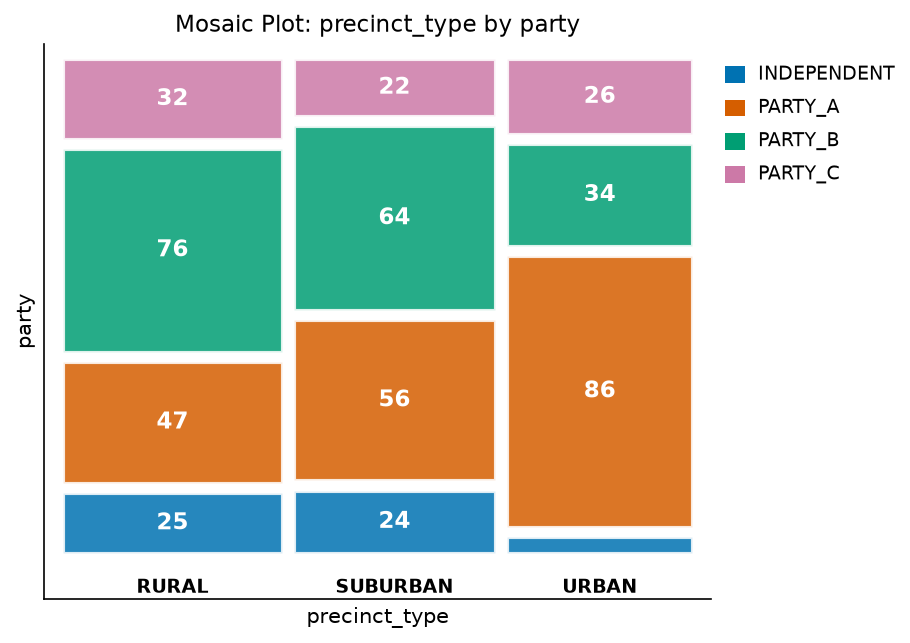

In [7]:
/* --------------------------------------------------------
   Export the precinct type x party summary for downstream
   redistricting impact assessment.
   -------------------------------------------------------- */
proc freq data=work.precinct_votes;
    tables precinct_type * party / out=work.voting_pattern_summary nocum;
run;

proc export data=work.voting_pattern_summary
    outfile='precinct_voting_patterns.csv'
    dbms=csv replace;
run;

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>